--- TUNING MODE: Processing C:\Users\E115881\OneDrive - RMIT University\Python\Ti image analysis\Updated Mask Training\patch_1.jpg ---
Measured Phase Fraction (White in Mask): 63.71%


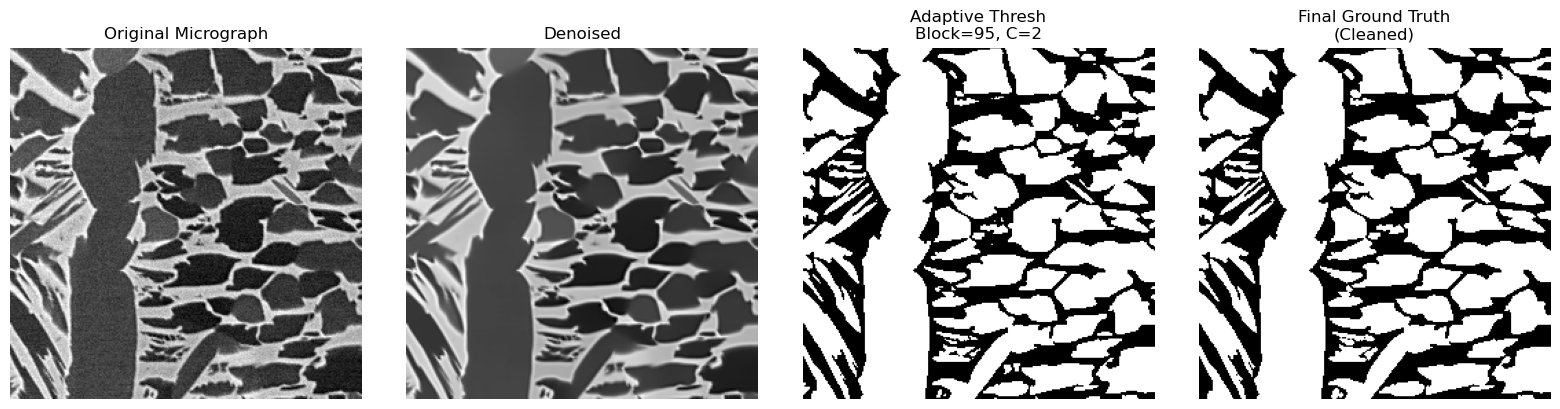

Check the plot. If satisfied, set TUNING_MODE = False to run batch.


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

#Script works in two setting, parameter tuning for the thresholding and then batch processing
#This is changed by TUNING_MODE = True/False, when true, select a single patch to test parameters and compare to orignal image, once happy
#with the settings, set to false to run all patches. Reccomend checking other created ground truth masks are as desired compared to original patches. 

# ==========================================
# USER PARAMETERS
# ==========================================
#Set which training iteration as same in 1_Training_Data_Prep for the patches, this will create the masks names with the same iteration number 
ground_truth_iteration = 1 #Set which masks interation image numbers this is i.e. 1, 2, 3, 4

# --- DIRECTORIES ---
# FIX: Added string quotes to define the paths
INPUT_FOLDER = "patches"  # Replace with your actual folder path
OUTPUT_FOLDER = "masks"   # Replace with your folder path to create the masks folder

# --- MODES ---
TUNING_MODE = True
TEST_IMAGE_NAME = 'patch_1.jpg' # Replace with your patch for testing

# --- PROCESSING SETTINGS ---
#These can be adjusted for patch thresholding

DENOISE_STRENGTH = 25 #Denoising 'smooths' image before thesholding 

THRESH_BLOCK_SIZE = 7 # BLOCK_SIZE: Size of pixel neighborhood (Must be an odd number: 11, 21, 31...)
THRESH_C = 2 # C: Constant subtracted from the mean (Fine tunes the cutoff)

MORPH_KERNEL_SIZE = 1
MIN_OBJECT_SIZE = 31

# ==========================================
# FUNCTIONS
# ==========================================

def process_image(img_path):
    # Load as Grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: Could not load {img_path}")
        return None
    
    # Step 1: Denoise
    denoised = cv2.fastNlMeansDenoising(img, None, h=DENOISE_STRENGTH, templateWindowSize=7, searchWindowSize=21)
    
    # Step 2: Adaptive Threshold
    # Note: You might need to raise 'C' slightly (e.g., to 3 or 4) to ensure the 
    # inside of the laths stays solid.
    thresh_raw = cv2.adaptiveThreshold(denoised, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                       cv2.THRESH_BINARY_INV, THRESH_BLOCK_SIZE, THRESH_C)
    
    # --- OPTIMIZED MORPHOLOGY ---
    # 1. Fill Holes (Close) FIRST. This seals the noisy gaps inside laths.
    kernel_close = np.ones((MORPH_KERNEL_SIZE, MORPH_KERNEL_SIZE), np.uint8)
    closed = cv2.morphologyEx(thresh_raw, cv2.MORPH_CLOSE, kernel_close, iterations=2) # Increased iterations to 2
    
    # 2. Remove Noise (Open) SECOND. Now that laths are solid, clean the background.
    kernel_open = np.ones((MORPH_KERNEL_SIZE, MORPH_KERNEL_SIZE), np.uint8)
    opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel_open, iterations=2)

    # Step 4: Fill remaining small holes explicitly
    # This function finds black holes inside white objects and fills them
    filled_mask = remove_small_holes(opened, MIN_OBJECT_SIZE) # See helper function below

    # Step 5: Remove small isolated objects (background noise)
    final_mask = remove_small_objects(filled_mask, MIN_OBJECT_SIZE)

     # Step 5: Calculate Phase Fraction
    total_pixels = final_mask.shape[0] * final_mask.shape[1]
    phase_pixels = cv2.countNonZero(final_mask)
    fraction = (phase_pixels / total_pixels) * 100

    return img, denoised, thresh_raw, final_mask, fraction
    
def remove_small_holes(binary_image, min_hole_size):
    img_copy = binary_image.copy()
    inv_image = cv2.bitwise_not(img_copy)
    
    contours, _ = cv2.findContours(inv_image, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    
    for cnt in contours:
        if cv2.contourArea(cnt) < min_hole_size:
            cv2.drawContours(img_copy, [cnt], 0, 255, -1)
            
    return img_copy

def remove_small_objects(mask, min_size):
    """Removes connected components smaller than min_size."""
    nb_components, output, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    sizes = stats[1:, -1] 
    nb_components = nb_components - 1

    clean_mask = np.zeros((output.shape), dtype=np.uint8)
    
    for i in range(0, nb_components):
        if sizes[i] >= min_size:
            clean_mask[output == i + 1] = 255
            
    return clean_mask
    
# ==========================================
# MAIN EXECUTION
# ==========================================

if __name__ == "__main__":
    
    # Ensure input folder exists
    if not os.path.exists(INPUT_FOLDER):
        print(f"CRITICAL ERROR: Input folder not found: {INPUT_FOLDER}")
        exit()

    if TUNING_MODE:
        # Construct full path to the test image
        test_path = os.path.join(INPUT_FOLDER, TEST_IMAGE_NAME)
        print(f"--- TUNING MODE: Processing {test_path} ---")
        
        result = process_image(test_path)
        
        if result:
            original, filtered, raw_thresh, final_mask, frac = result
            print(f"Measured Phase Fraction (White in Mask): {frac:.2f}%")
            
            # Visualization
            plt.figure(figsize=(16, 4))
            
            plt.subplot(1, 4, 1)
            plt.imshow(original, cmap='gray')
            plt.title('Original Micrograph')
            plt.axis('off')

            plt.subplot(1, 4, 2)
            plt.imshow(filtered, cmap='gray')
            plt.title('Denoised')
            plt.axis('off')
        
            plt.subplot(1, 4, 3)
            plt.imshow(raw_thresh, cmap='gray')
            plt.title(f'Adaptive Thresh\nBlock={THRESH_BLOCK_SIZE}, C={THRESH_C}')
            plt.axis('off')

            plt.subplot(1, 4, 4)
            plt.imshow(final_mask, cmap='gray')
            plt.title(f'Final Ground Truth\n(Cleaned)')
            plt.axis('off')

            plt.tight_layout()
            plt.show()
            print("Check the plot. If satisfied, set TUNING_MODE = False to run batch.")

    else:
        # --- BATCH MODE ---
        print(f"--- BATCH MODE: Processing images from {INPUT_FOLDER} ---")
        
        # Create output directory if it doesn't exist
        if not os.path.exists(OUTPUT_FOLDER):
            os.makedirs(OUTPUT_FOLDER)
            print(f"Created output folder: {OUTPUT_FOLDER}")

        # Find all jpg images in the input folder
        search_pattern = os.path.join(INPUT_FOLDER, "*.jpg")
        image_files = glob.glob(search_pattern) 
        
        print(f"Found {len(image_files)} images.")

        for fpath in image_files:
            res = process_image(fpath)
            if res:
                _, _, _, mask, frac = res
                
                base_name = os.path.basename(fpath)
                name_without_ext = os.path.splitext(base_name)[0]
                save_name = os.path.join(OUTPUT_FOLDER, f"{name_without_ext}_mask.png")
                
                cv2.imwrite(save_name, mask)
                print(f"Processed {base_name}: {frac:.2f}% phase fraction. Saved to {save_name}")

        print("Batch processing complete.")

NameError: name 'denoised' is not defined